/tmp/ipykernel_1724022/2752523141.py:81: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  figure.show()


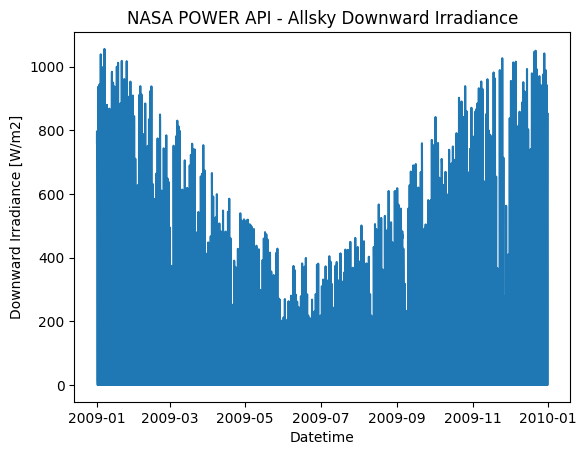

In [31]:
import requests

from datetime import datetime

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from loguru import logger


def get_allsky_irradiance(longitude: float, latitude: float, start_date: str, end_date: str, time_standard: str="UTC") -> pd.DataFrame:
    """
    Retrieve hourly all-sky downward irradiance (ALLSKY_SFC_SW_DWN) from NASA POWER API.

    Parameters:
        longitude: Longitude in decimal degrees.
        latitude: Latitude in decimal degrees.
        start_date: Start date, format 'YYYYMMDD'.
        end_date: End date, format 'YYYYMMDD'.
        time_standard: 'UTC' or 'LST' (Local Solar Time).

    Returns:
        pd.DataFrame: DataFrame of results.
    """
    assert longitude > -180 and longitude < 180, f"longitude must be between -180 and 180, got: {longitude}"
    assert latitude > -90 and latitude < 90, f"latitude must be between -90 and 90, got: {latitude}"
    
    url: str = (
        f"https://power.larc.nasa.gov/api/temporal/hourly/point?"
        f"parameters=ALLSKY_SFC_SW_DWN"
        f"&community=RE"
        f"&longitude={longitude}"
        f"&latitude={latitude}"
        f"&start={start_date}"
        f"&end={end_date}"
        f"&format=JSON"
        f"&time-standard={time_standard}"
    )

    response: requests.Response = requests.get(url)
    response.raise_for_status()
    data: dict = response.json()

    # Parse data
    hours: dict[str, float] = data["properties"]["parameter"]["ALLSKY_SFC_SW_DWN"]
    records = [
        {"datetime": date, "ALLSKY_SFC_SW_DWN": value}
        for date, value in hours.items()
    ]
    df: pd.DataFrame = pd.DataFrame(records)
    df["datetime"] = pd.to_datetime(df["datetime"], format="%Y%m%d%H")
    return df


# Example usage:
if __name__ == "__main__":
    
    # NOTE: Elephant rocks, Tasmania
    longitude: float = 148.34169
    latitude: float = -41.25289

    # Start and end date in format YYYYMMDD
    start_date: str = "20090101"
    end_date: str = "20091231"

    df: pd.DataFrame = get_allsky_irradiance(
        longitude=longitude,
        latitude=latitude,
        start_date=start_date,
        end_date=end_date,
        time_standard="UTC"
    )

    # Viusalize
    figure: plt.Figure = plt.figure()
    ax: plt.Axes = sns.lineplot(x=df["datetime"], y=df["ALLSKY_SFC_SW_DWN"])
    ax.set_xlabel("Datetime")
    ax.set_ylabel("Downward Irradiance [W/m2]")
    ax.set_title("NASA POWER API - Allsky Downward Irradiance")
    figure.show()
